# E-Commerce Sales & Profitability Analysis

This project analyzes the Superstore e-commerce dataset to understand sales performance, profitability, product performance, and the relationship between discount levels and profit.

## Business Questions

1. How does sales and profit performance change over time?
2. Which product categories generate the most revenue and profit?
3. Which sub-categories are the most and least profitable?
4. How does discounting relate to profitability?

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Load Dataset

In [2]:
df = pd.read_csv(
    "../data/Superstore.csv",
    encoding="windows-1252"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 3. Initial Data Exploration

In [3]:
print(f"Dataset shape: {df.shape}")

df.info()

display(df.describe())
display(df.isnull().sum().to_frame("missing_values"))
print(f"Duplicate rows: {df.duplicated().sum()}")

Dataset shape: (9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-nu

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


,missing_values
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Duplicate rows: 0


## 4. Data Cleaning & Feature Engineering

In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()
df["year_month"] = df["order_date"].dt.to_period("M").astype(str)
df["profit_margin"] = (df["profit"] / df["sales"]) * 100
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,year,month,month_name,year_month,profit_margin,shipping_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,2016-11,16.00,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,2016-11,30.00,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2016-06,47.00,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,2015-10,-40.00,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,2015-10,11.25,7


In [5]:
df.to_csv(
    "../data/cleaned_superstore.csv",
    index=False,
    encoding="utf-8"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  sub_category   9994 n

## 5. Key Performance Indicators

In [6]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()
profit_margin = (total_profit / total_sales) * 100
average_order_value = total_sales / total_orders
average_shipping_days = df["shipping_days"].mean()

kpi = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Average Shipping Time"
    ],
    "Value": [
        total_sales,
        total_profit,
        profit_margin,
        total_orders,
        total_customers,
        average_order_value,
        average_shipping_days
    ]
})

kpi

,Metric,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Profit Margin,1.246722e+01
3,Total Orders,5.009000e+03
4,Total Customers,7.930000e+02
5,Average Order Value,4.586147e+02
6,Average Shipping Time,3.958175e+00


## 6. Sales Trend Analysis

This section analyzes annual and monthly sales and profit performance to identify growth trends and changes in profitability.

In [7]:
yearly_performance = (
    df.groupby("year")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

yearly_performance["profit_margin"] = (
    yearly_performance["total_profit"]
    / yearly_performance["total_sales"]
) * 100

yearly_performance["sales_growth"] = (
    yearly_performance["total_sales"].pct_change() * 100
)

yearly_performance["profit_growth"] = (
    yearly_performance["total_profit"].pct_change() * 100
)

yearly_performance.round(2)

,year,total_sales,total_profit,total_orders,profit_margin,sales_growth,profit_growth
0,2014,484247.50,49543.97,969,10.23,NaN,NaN
1,2015,470532.51,61618.60,1038,13.10,-2.83,24.37
2,2016,609205.60,81795.17,1315,13.43,29.47,32.74
3,2017,733215.26,93439.27,1687,12.74,20.36,14.24


In [8]:
monthly_performance = (
    df.groupby("year_month")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

top_sales_months = (
    monthly_performance
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_profit_months = (
    monthly_performance
    .sort_values("total_profit", ascending=False)
    .head(10)
)

display(monthly_performance.head())
display(top_sales_months)
display(top_profit_months)

,year_month,total_sales,total_profit,total_orders
0,2014-01,14236.895,2450.1907,32
1,2014-02,4519.892,862.3084,28
2,2014-03,55691.009,498.7299,71
3,2014-04,28295.345,3488.8352,66
4,2014-05,23648.287,2738.7096,69


,year_month,total_sales,total_profit,total_orders
46,2017-11,118447.8250,9690.1037,261
35,2016-12,96999.0430,17885.3093,176
44,2017-09,87866.6520,10991.5556,226
47,2017-12,83829.3188,8483.3468,224
8,2014-09,81777.3508,8328.0994,130
34,2016-11,79411.9658,4011.4075,183
10,2014-11,78628.7167,9292.1269,151
45,2017-10,77776.9232,9275.2755,147
22,2015-11,75972.5635,12474.7884,158
23,2015-12,74919.5212,8016.9659,161


,year_month,total_sales,total_profit,total_orders
35,2016-12,96999.0430,17885.3093,176
33,2016-10,59687.7450,16243.1425,105
38,2017-03,58872.3528,14751.8915,118
22,2015-11,75972.5635,12474.7884,158
44,2017-09,87866.6520,10991.5556,226
14,2015-03,38726.2520,9732.0978,79
46,2017-11,118447.8250,9690.1037,261
32,2016-09,73410.0249,9328.6576,192
10,2014-11,78628.7167,9292.1269,151
45,2017-10,77776.9232,9275.2755,147


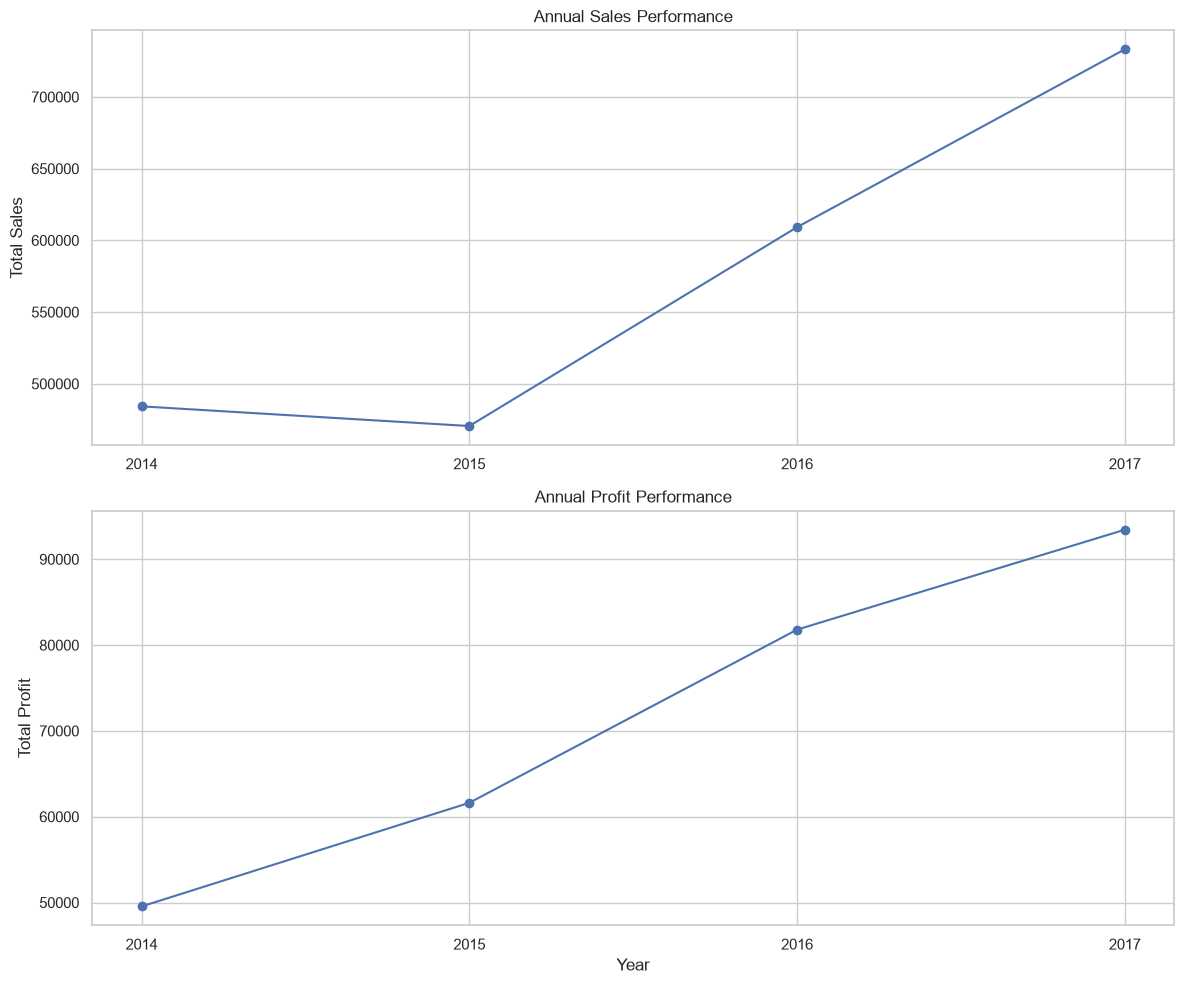

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(
    yearly_performance["year"],
    yearly_performance["total_sales"],
    marker="o"
)
axes[0].set_title("Annual Sales Performance")
axes[0].set_ylabel("Total Sales")
axes[0].set_xticks(yearly_performance["year"])

axes[1].plot(
    yearly_performance["year"],
    yearly_performance["total_profit"],
    marker="o"
)
axes[1].set_title("Annual Profit Performance")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Total Profit")
axes[1].set_xticks(yearly_performance["year"])

plt.tight_layout()
plt.savefig(
    "../visualization/annual_sales_profit.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

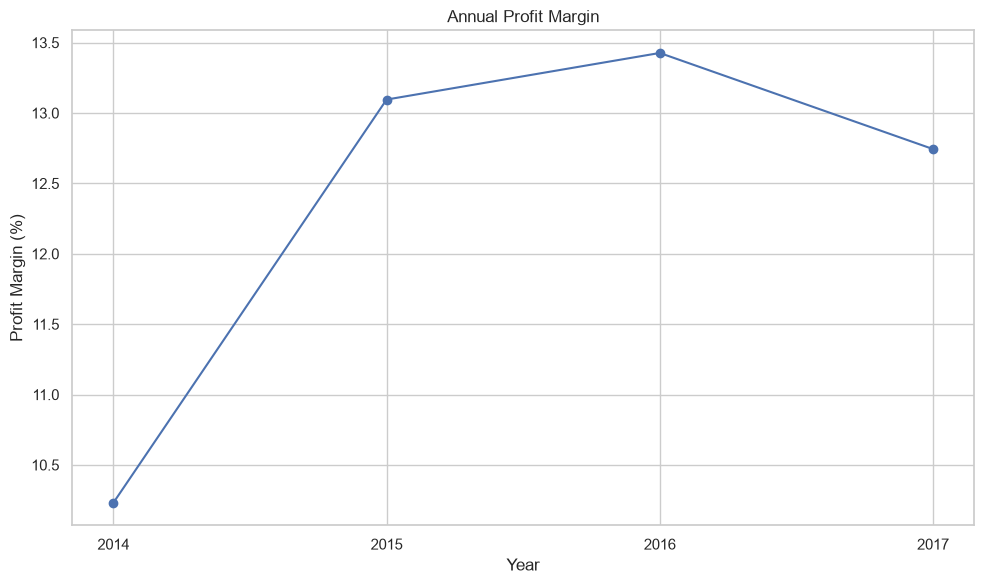

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(
    yearly_performance["year"],
    yearly_performance["profit_margin"],
    marker="o"
)
plt.title("Annual Profit Margin")
plt.xlabel("Year")
plt.ylabel("Profit Margin (%)")
plt.xticks(yearly_performance["year"])
plt.tight_layout()
plt.savefig(
    "../visualization/annual_profit_margin.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

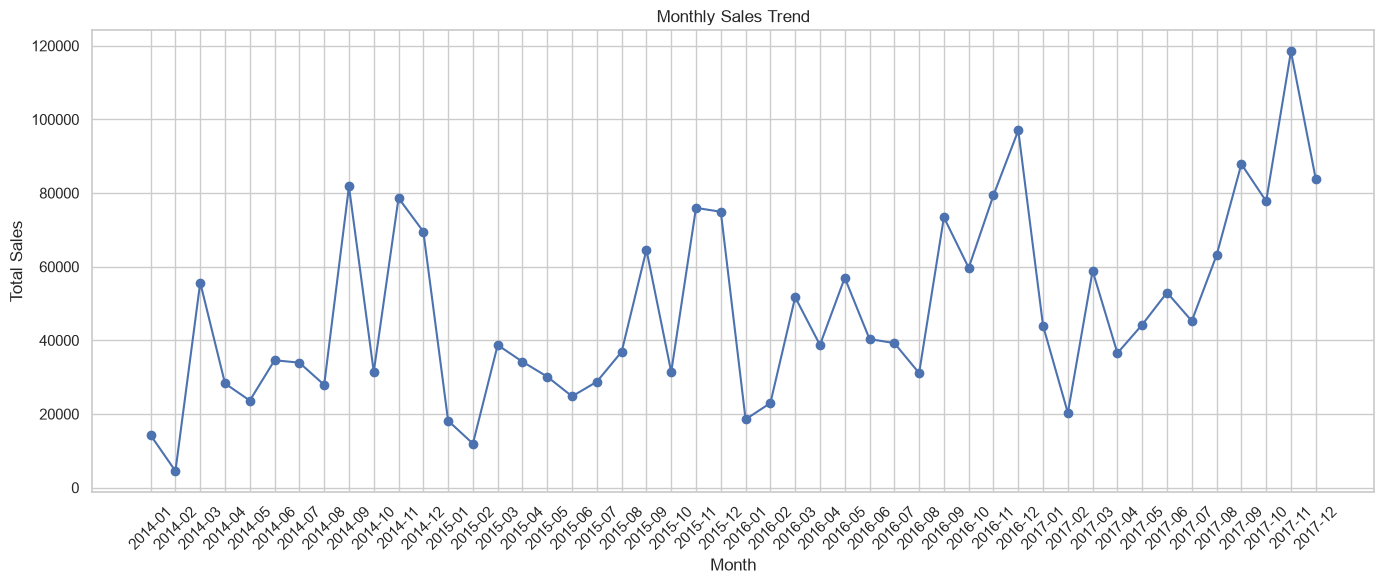

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(
    monthly_performance["year_month"],
    monthly_performance["total_sales"],
    marker="o"
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "../visualization/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Initial Findings

- Sales declined by 2.83% in 2015, while profit increased by 24.37%.
- 2016 recorded the strongest sales and profit growth.
- Profit margin peaked at 13.43% in 2016.
- In 2017, sales continued to grow, but profit growth slowed significantly.
- Profit margin declined from 13.43% in 2016 to 12.74% in 2017.

## 7. Product Category Analysis

This section compares sales, profit, quantity, orders, and profit margin across product categories.

In [12]:
category_performance = (
    df.groupby("category")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

category_performance["profit_margin"] = (
    category_performance["total_profit"]
    / category_performance["total_sales"]
) * 100

category_performance = category_performance.sort_values(
    "total_sales",
    ascending=False
)

category_performance.round(2)

,category,total_sales,total_profit,total_quantity,total_orders,profit_margin
2,Technology,836154.03,145454.95,6939,1544,17.40
0,Furniture,741999.80,18451.27,8028,1764,2.49
1,Office Supplies,719047.03,122490.80,22906,3742,17.04


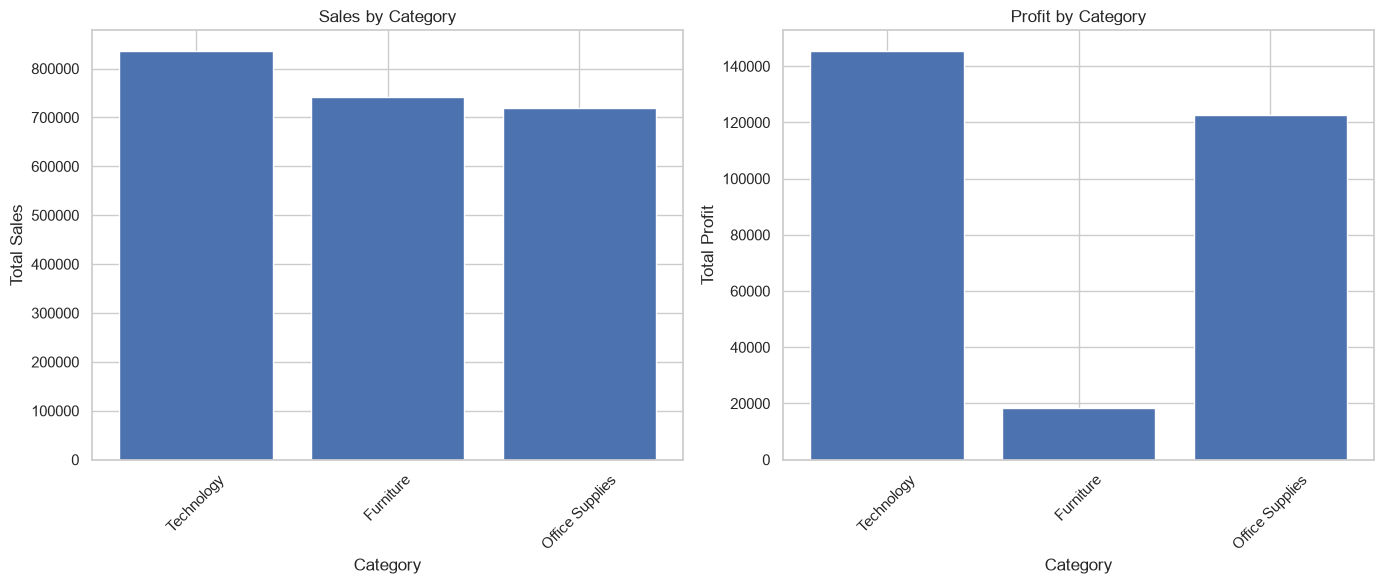

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(
    category_performance["category"],
    category_performance["total_sales"]
)
axes[0].set_title("Sales by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Sales")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(
    category_performance["category"],
    category_performance["total_profit"]
)
axes[1].set_title("Profit by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Total Profit")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(
    "../visualization/category_sales_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Initial Findings

- Technology generated the highest sales and the highest profit margin at 17.40%.
- Office Supplies achieved a profit margin of 17.04%.
- Furniture generated approximately $742,000 in sales but had a profit margin of only 2.49%.
- Furniture is the category with the most significant profitability concern.

## 8. Sub-Category Profitability Analysis

This section identifies the sub-categories contributing most and least to profitability.

In [14]:
subcategory_performance = (
    df.groupby("sub_category")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

subcategory_performance["profit_margin"] = (
    subcategory_performance["total_profit"]
    / subcategory_performance["total_sales"]
) * 100

subcategory_profit = subcategory_performance.sort_values(
    "total_profit"
)

subcategory_profit.round(2)

,sub_category,total_sales,total_profit,total_quantity,total_orders,profit_margin
16,Tables,206965.53,-17725.48,1241,307,-8.56
4,Bookcases,114880.00,-3472.56,868,224,-3.02
15,Supplies,46673.54,-1189.10,647,187,-2.55
8,Fasteners,3024.28,949.52,914,215,31.40
11,Machines,189238.63,3384.76,440,112,1.79
10,Labels,12486.31,5546.25,1400,346,44.42
2,Art,27118.79,6527.79,3000,731,24.07
7,Envelopes,16476.40,6964.18,906,249,42.27
9,Furnishings,91705.16,13059.14,3563,877,14.24
1,Appliances,107532.16,18138.01,1729,451,16.87


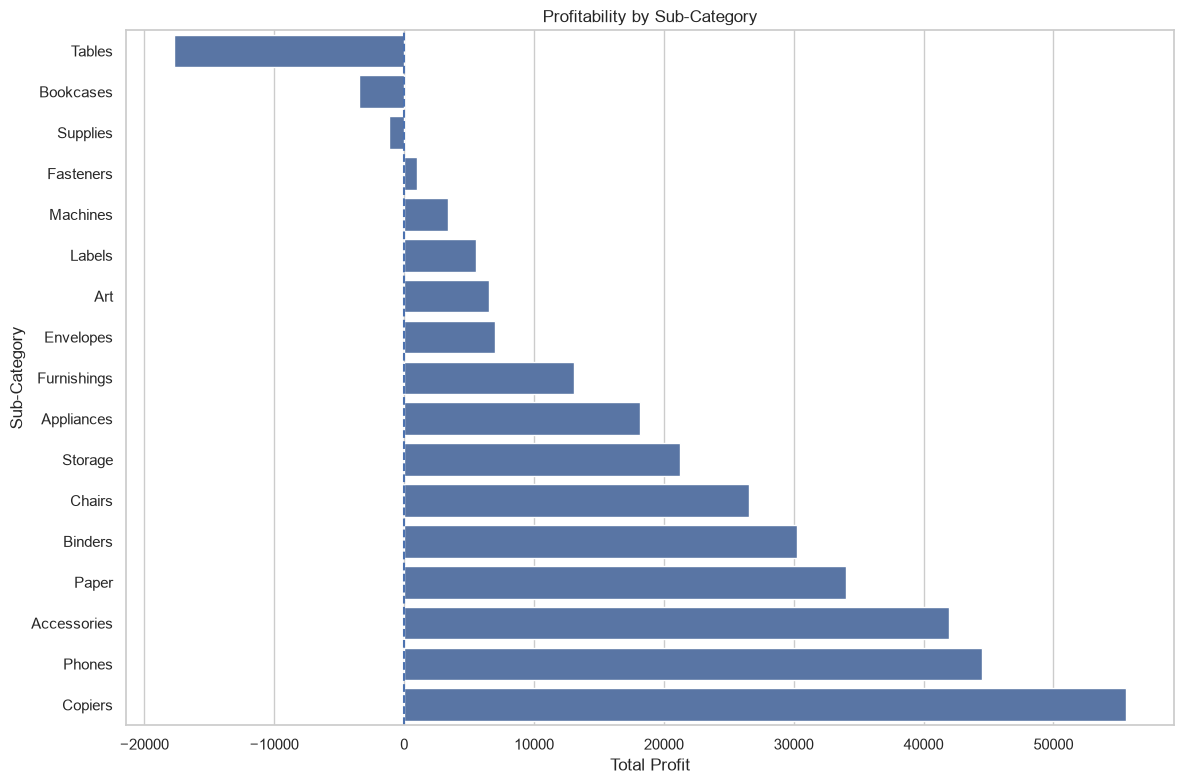

In [15]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=subcategory_profit,
    x="total_profit",
    y="sub_category"
)
plt.axvline(0, linestyle="--")
plt.title("Profitability by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.savefig(
    "../visualization/subcategory_profitability.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Initial Findings

- Tables generated the largest loss at approximately USD-17,725, with a profit margin of -8.56%.
- Bookcases and Supplies also generated negative profit.
- Copiers generated the highest total profit at approximately USD55,618.
- Phones and Accessories also ranked among the strongest contributors to profit.

## 9. Discount and Profitability Analysis

This section investigates the relationship between discount levels and profitability. The analysis is observational and does not establish that discounts alone caused losses.

In [16]:
discount_performance = (
    df.groupby("discount")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_orders=("order_id", "nunique"),
        average_profit=("profit", "mean")
    )
    .reset_index()
)

discount_performance["profit_margin"] = (
    discount_performance["total_profit"]
    / discount_performance["total_sales"]
) * 100

discount_performance.round(2)

,discount,total_sales,total_profit,total_orders,average_profit,profit_margin
0,0.00,1087908.47,320987.60,2644,66.90,29.51
1,0.10,54369.35,9029.18,89,96.06,16.61
2,0.15,27558.52,1418.99,51,27.29,5.15
3,0.20,764594.37,90337.31,2407,24.70,11.82
4,0.30,103226.66,-10369.28,211,-45.68,-10.05
5,0.32,14493.46,-2391.14,27,-88.56,-16.50
6,0.40,116417.78,-23057.05,185,-111.93,-19.81
7,0.45,5484.97,-2493.11,10,-226.65,-45.45
8,0.50,58918.54,-20506.43,64,-310.70,-34.80
9,0.60,6644.70,-5944.66,127,-43.08,-89.46


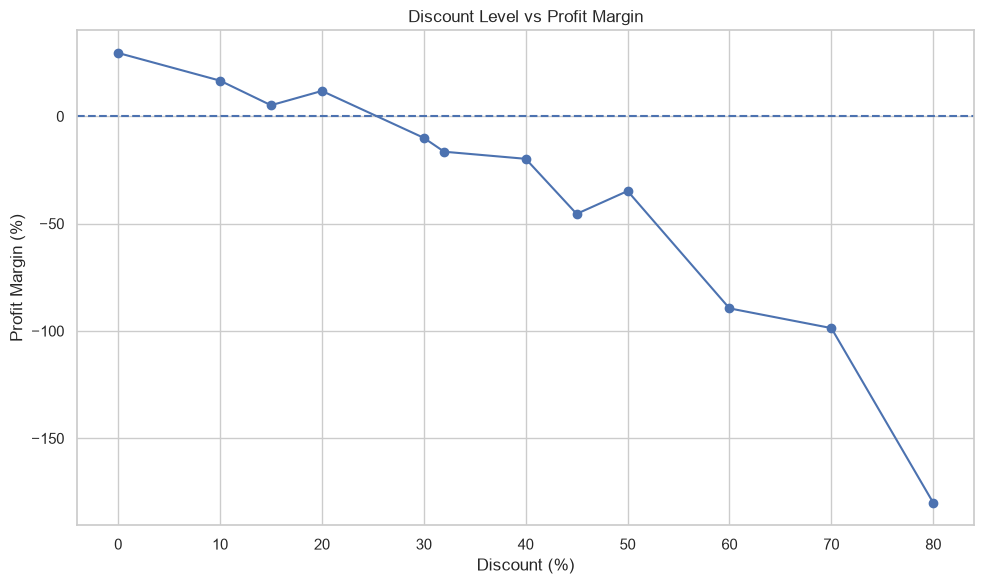

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(
    discount_performance["discount"] * 100,
    discount_performance["profit_margin"],
    marker="o"
)
plt.axhline(0, linestyle="--")
plt.title("Discount Level vs Profit Margin")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.savefig(
    "../visualization/discount_vs_profit_margin.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [18]:
negative_discount_levels = discount_performance[
    discount_performance["total_profit"] < 0
]

negative_discount_levels.round(2)

,discount,total_sales,total_profit,total_orders,average_profit,profit_margin
4,0.30,103226.66,-10369.28,211,-45.68,-10.05
5,0.32,14493.46,-2391.14,27,-88.56,-16.50
6,0.40,116417.78,-23057.05,185,-111.93,-19.81
7,0.45,5484.97,-2493.11,10,-226.65,-45.45
8,0.50,58918.54,-20506.43,64,-310.70,-34.80
9,0.60,6644.70,-5944.66,127,-43.08,-89.46
10,0.70,40620.28,-40075.36,344,-95.87,-98.66
11,0.80,16963.76,-30539.04,250,-101.80,-180.03


### Initial Findings

- The 0% discount group recorded a 29.51% profit margin.
- The 20% discount group recorded an 11.82% profit margin.
- The first discount level associated with negative aggregate profit was 30%.
- Higher discount levels were strongly associated with lower profitability and negative profit margins.
- The 70% and 80% discount groups recorded particularly severe negative profit margins.

## Current Key Findings

1. 2016 recorded the strongest annual sales and profit growth.
2. Sales continued to grow in 2017, but profit growth slowed and profit margin declined.
3. Technology was the strongest category in terms of sales and profit margin.
4. Furniture generated substantial sales but had significantly lower profitability than the other major categories.
5. Tables were the largest source of sub-category losses.
6. Higher discount levels were strongly associated with lower profitability, with aggregate profit becoming negative at the 30% discount level.

These findings should be validated with additional analysis before final business recommendations are made.

## 10. Regional Performance Analysis

This section analyzes sales and profitability across different regions to identify regional performance differences and potential areas for improvement.

The analysis compares total sales, total profit, total quantity sold, total orders, total customers, and profit margin across regions.

In [19]:
regional_performance = (
    df.groupby("region")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        total_orders=("order_id", "nunique"),
        total_customers=("customer_id", "nunique")
    )
    .reset_index()
)

regional_performance["profit_margin"] = (
    regional_performance["total_profit"]
    / regional_performance["total_sales"]
) * 100

regional_performance = regional_performance.sort_values(
    "total_sales",
    ascending=False
)

regional_performance.round(2)

,region,total_sales,total_profit,total_quantity,total_orders,total_customers,profit_margin
3,West,725457.82,108418.45,12266,1611,686,14.94
1,East,678781.24,91522.78,10618,1401,674,13.48
0,Central,501239.89,39706.36,8780,1175,629,7.92
2,South,391721.90,46749.43,6209,822,512,11.93


### Regional Findings

- The West region generated the highest total sales at approximately USD 725,458.
- The West region also generated the highest total profit at approximately USD 108,418.
- The West region recorded the highest profit margin at 14.94%.
- The Central region had the lowest profit margin at 7.92%, indicating a significant profitability gap compared with the other regions.
- The South region generated the lowest total sales but achieved a higher profit margin than the Central region.

### Business Interpretation

The West region is the strongest overall performer in terms of both sales and profitability.

The Central region requires further investigation because it generated substantial sales but had the lowest profit margin among all regions. This may indicate differences in product mix, discount levels, customer segments, or operating performance.

The South region also demonstrates an interesting pattern: despite having the lowest sales volume, its profit margin is higher than the Central region. This suggests that sales volume alone does not determine regional profitability.

## 11. Product Performance Analysis

This section identifies the products that generate the highest sales and profit, as well as products that contribute the most to overall losses.

In [20]:
product_performance = (
    df.groupby(["product_id", "product_name"])
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

product_performance["profit_margin"] = (
    product_performance["total_profit"]
    / product_performance["total_sales"]
) * 100

top_products_sales = (
    product_performance
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_products_profit = (
    product_performance
    .sort_values("total_profit", ascending=False)
    .head(10)
)

loss_making_products = (
    product_performance
    .sort_values("total_profit")
    .head(10)
)

display(top_products_sales.round(2))
display(top_products_profit.round(2))
display(loss_making_products.round(2))

,product_id,product_name,total_sales,total_profit,total_quantity,total_orders,profit_margin
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,20,5,40.91
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38,7753.04,31,10,28.24
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.48,-1811.08,6,1,-8.00
82,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,21870.58,0.00,39,8,0.00
701,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,19823.48,2233.51,37,11,11.27
667,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,19024.50,760.98,48,9,4.00
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,38,8,37.07
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.90,4094.98,12,3,22.29
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,27,6,-10.45
1443,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,17030.31,-262.00,11,3,-1.54


,product_id,product_name,total_sales,total_profit,total_quantity,total_orders,profit_margin
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,20,5,40.91
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38,7753.04,31,10,28.24
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,38,8,37.07
1637,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.83,4570.93,19,4,39.34
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.90,4094.98,12,3,22.29
1693,TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,7699.89,3772.95,11,2,49.00
1656,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.89,3717.97,11,2,26.00
1541,TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless He...,9367.29,3696.28,24,7,39.46
692,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,15875.92,3345.28,13,3,21.07
1643,TEC-MA-10000045,Zebra ZM400 Thermal Label Printer,6965.70,3343.54,6,2,48.00


,product_id,product_name,total_sales,total_profit,total_quantity,total_orders,profit_margin
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.96,-8879.97,9,3,-80.00
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.90,-4589.97,18,4,-27.27
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.98,-3839.99,4,1,-48.00
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.64,-2876.12,27,5,-29.00
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.72,-1934.40,33,7,-20.27
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,27,6,-10.45
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.48,-1811.08,6,1,-8.00
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,16656.20,-1299.18,22,6,-7.80
346,FUR-TA-10001950,Balt Solid Wood Round Tables,6518.75,-1201.06,19,4,-18.42
375,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,1706.25,-1148.44,15,3,-67.31


In [21]:
def shorten_product_name(name, max_length=35):
    if len(name) > max_length:
        return name[:max_length] + "..."
    return name


sales_plot = top_products_sales.sort_values("total_sales").copy()
loss_plot = loss_making_products.sort_values(
    "total_profit",
    ascending=False
).copy()

sales_plot["short_name"] = sales_plot["product_name"].apply(
    shorten_product_name
)

loss_plot["short_name"] = loss_plot["product_name"].apply(
    shorten_product_name
)

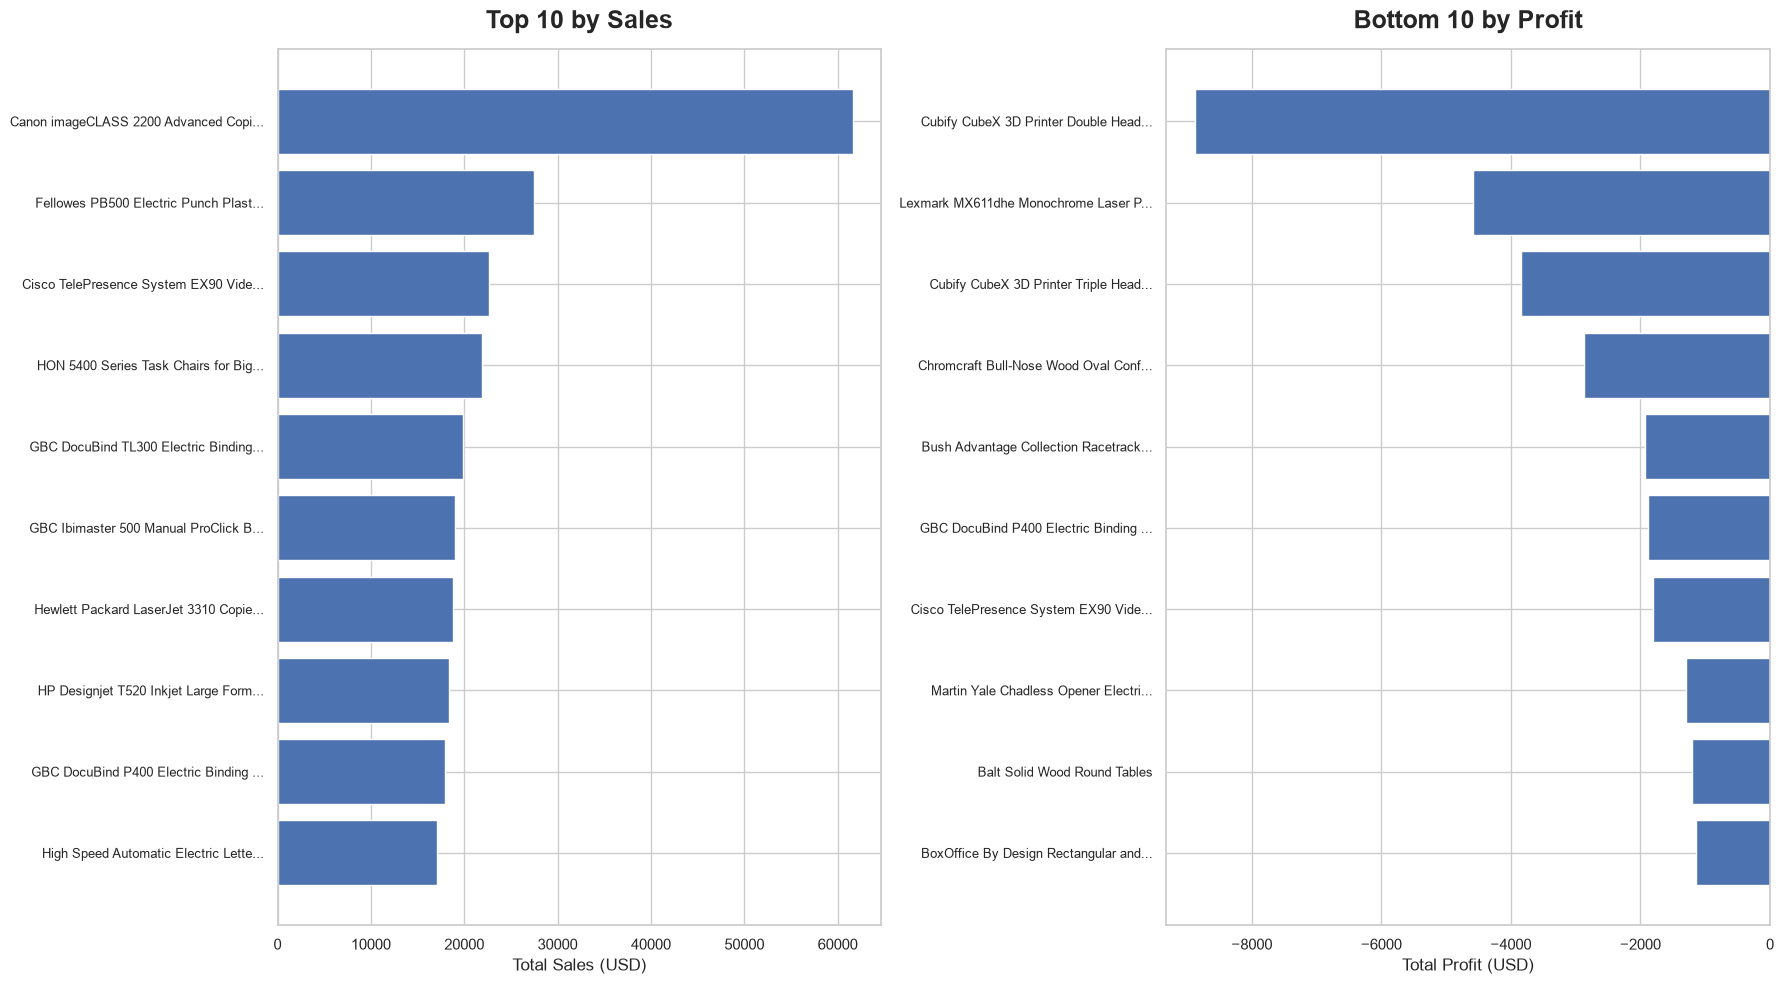

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

axes[0].barh(
    sales_plot["short_name"],
    sales_plot["total_sales"]
)

axes[0].set_title(
    "Top 10 by Sales",
    fontsize=18,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("Total Sales (USD)")
axes[0].set_ylabel("")
axes[0].tick_params(axis="y", labelsize=9)


axes[1].barh(
    loss_plot["short_name"],
    loss_plot["total_profit"]
)

axes[1].set_title(
    "Bottom 10 by Profit",
    fontsize=18,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel("Total Profit (USD)")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", labelsize=9)


plt.tight_layout()

plt.savefig(
    "../visualization/top_sales_vs_loss_making_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Product Findings

The top-selling products are not necessarily the most profitable products. Therefore, sales volume should be evaluated together with total profit and profit margin.

Products with the lowest total profit require further investigation, particularly in relation to discount levels, product category, and regional sales patterns.

## 12. Key Business Findings

### Sales and Growth

- Sales performance generally improved over the four-year period.
- 2016 recorded the strongest overall growth in both sales and profit.
- In 2017, sales continued to grow, but profit growth slowed and profit margin declined.

### Category Performance

- Technology was the strongest major category in terms of profitability.
- Office Supplies also maintained a strong profit margin.
- Furniture generated substantial sales but had significantly lower profitability.

### Sub-Category Performance

- Tables were the largest source of sub-category losses.
- Bookcases and Supplies also generated negative profit.
- Copiers, Phones, and Accessories were among the strongest profit contributors.

### Regional Performance

- West was the strongest region in terms of sales, total profit, and profit margin.
- Central had the lowest profit margin despite generating substantial sales.
- South generated the lowest sales but achieved a higher profit margin than Central.

### Discount and Profitability

- Higher discount levels were strongly associated with lower profitability.
- Aggregate profit became negative at the 30% discount level.
- Very high discount levels were associated with particularly severe negative profit margins.

These findings are observational and should be further investigated before making causal business decisions.

## 13. Conclusion

The analysis shows that the business experienced overall sales growth, but revenue growth did not always translate into proportional profit growth.

The main profitability concerns were concentrated in the Furniture category, particularly the Tables sub-category, and in transactions with higher discount levels.

The West region demonstrated the strongest overall performance, while the Central region showed the largest profitability gap.

The key business opportunity is to investigate pricing, discount strategies, product-level profitability, and regional performance in greater detail. Future analysis should examine the interaction between discounts, product categories, regions, and customer segments to identify the specific factors driving negative profit.